In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import contextily as ctx
import pandas as pd


pd.set_option('display.max_columns', 500)

In [2]:
with open('gdf_ht.pickle', 'rb') as file:
    gdf_ht =  pickle.load(file)

In [4]:
with open('warsaw.pickle', 'rb') as file:
    warsaw =  pickle.load(file)

In [5]:
with open('powiaty_maz.pickle', 'rb') as file:
    powiaty_maz =  pickle.load(file)

In [6]:
with open('dzielnice.pickle', 'rb') as file:
    dzielnice =  pickle.load(file)

In [7]:
with open('gdf.pickle', 'rb') as file:
    gdf =  pickle.load(file)

In [8]:
pkd7 = pd.read_excel('C:\\Studia\\Master\\master_thesis\\data\\PKD7_HT.xlsx')

In [9]:
pkd7

,PKD7,Group
0,0111Z,O
1,0112Z,O
2,0113Z,O
3,0114Z,O
4,0115Z,O
...,...,...
649,9609Z,O
650,9700Z,O
651,9810Z,O
652,9820Z,O


In [10]:
gdf = pd.merge(gdf, pkd7, on='PKD7', how='left')

In [11]:
gdf['tech'].value_counts()

tech
high-tech know-intens serv    34321
medium-high-tech               5847
high-tech                      2173
Name: count, dtype: int64

In [12]:
gdf['tech'].fillna('other', inplace=True)

C:\Users\Filip\AppData\Local\Temp\ipykernel_30680\1097909830.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  gdf['tech'].fillna('other', inplace=True)


In [13]:
gdf['Group'].value_counts()

Group
O        718731
KIS      131016
HTKIS     56774
MLT       37023
LT        30192
MHT        5862
HT         2173
PMHT       1944
Name: count, dtype: int64

In [14]:
warsaw.head()

,?,ID,REGON,POWIAT,GMINA,Address_full,SEK_PKD7,PKD7,GR_LPRAC,lon,lat,tech,if_hightech,empl,sharesEMPL2,ones,locPdens,locAggA,locAggB,locAggC,locAggD,locAggE,locAggF,locAggG,locAggH,locAggI,locAggJ,locAggK,locAggL,locAggM,locAggN,locAggO,locAggP,locAggQ,locAggR,locAggS,locAggT,locAggU,locHH,locBIG,locAggTOTAL,locHightech,locLQ,dist_core_10,dist_core_25,dist_core_50,dist_midsize_10,dist_midsize_25,dist_midsize_50,dist_regional_10,dist_regional_25,dist_regional_50,dist_localbig_10,dist_localbig_25,dist_localbig_50,dist_localsmall_10,dist_localsmall_25,dist_localsmall_50,COREfirms,COREpopul,geometry,index_right,nazwa_dzie
2,118240,3,1.109380e+12,65,58,Ignacego Krasickiego 12A 02-611 Warszawa,G,4690Z,1,21.02140,52.19191,NaN,0,5.001276,1.518227e-11,1,203,72,4,141,24,12,192,620,111,64,203,98,185,533,121,0,89,101,51,207,0,1,2.685278e-07,34,2829,183,1.126141,1,1,1,0,0,0,0,1,1,0,1,1,1,1,1,1,1,POINT (21.02140 52.19191),2,Mokotów
3,210007,4,1.566525e+12,65,188,al. Prymasa Tysiąclecia 62 01-424 Warszawa,G,4643Z,1,20.95726,52.23474,NaN,0,5.114140,1.587524e-11,1,220,10,1,35,3,4,47,133,25,27,42,19,54,111,29,3,25,24,12,38,0,0,3.089481e-08,6,642,49,1.064512,1,1,1,0,0,0,0,1,1,0,1,1,0,1,1,1,1,POINT (20.95726 52.23474),3,Wola
4,423467,5,1.401995e+13,65,48,Marymoncka 93/97 01-813 Warszawa,S,9511Z,1,20.95403,52.28521,NaN,0,4.939015,1.787151e-10,1,150,50,0,172,2,2,166,505,110,59,143,66,105,323,104,1,106,111,69,164,0,0,5.495024e-07,16,2258,141,1.584181,1,1,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1,POINT (20.95403 52.28521),15,Bielany
6,423483,7,1.261750e+12,65,118,Młodzieńcza 6A 03-655 Warszawa,G,4531Z,1,21.07405,52.28819,NaN,0,5.069210,1.559752e-11,1,63,39,1,189,4,3,146,583,139,37,127,48,58,209,65,1,58,59,24,103,0,0,6.196419e-08,14,1893,133,1.582529,1,1,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1,POINT (21.07405 52.28819),12,Targówek
7,423491,8,1.615877e+12,65,28,Sternicza 109 01-350 Warszawa,M,7022Z,1,20.90667,52.22091,NaN,0,4.945351,6.145639e-11,1,110,117,1,231,6,3,246,747,224,53,175,107,55,348,129,0,80,111,30,159,0,0,1.391550e-07,13,2822,190,1.240861,0,1,1,0,0,0,0,1,1,0,1,1,1,1,1,1,1,POINT (20.90667 52.22091),17,Bemowo


if_hightech = high-tech, medium high-tech, knowledge intensive

In [15]:
warsaw_ht = warsaw[warsaw['if_hightech'] == 1]

In [16]:
import math

lon = 21.017532
lat = 52.237049


one_km_in_degrees_lat = 1 / 111.32
one_km_in_degrees_lon = 1 / (111.32 * math.cos(math.radians(lat)))

grid_size = min(one_km_in_degrees_lat, one_km_in_degrees_lon)

print("Grid Size for Approximately 1 km Grid:", grid_size, "degrees")

average_grid_size = (one_km_in_degrees_lat + one_km_in_degrees_lon) / 2

print("Average Grid Size for Approximately 1 km Grid:", average_grid_size, "degrees")


Grid Size for Approximately 1 km Grid: 0.008983111749910169 degrees
Average Grid Size for Approximately 1 km Grid: 0.011825953794919259 degrees


In [17]:
min_lon_maz, max_lon_maz = gdf_ht['lon'].min(), gdf_ht['lon'].max()
min_lat_maz, max_lat_maz = gdf_ht['lat'].min(), gdf_ht['lat'].max()
grid_size = 0.01182 

lons_maz = np.arange(min_lon_maz, max_lon_maz, grid_size)
lats_maz = np.arange(min_lat_maz, max_lat_maz, grid_size)

gdf_ht['grid_x_maz_ht'] = np.digitize(gdf_ht['lon'], lons_maz)
gdf_ht['grid_y_maz_ht'] = np.digitize(gdf_ht['lat'], lats_maz)

grid_counts_maz = gdf_ht.groupby(['grid_x_maz_ht', 'grid_y_maz_ht']).size().reset_index(name='firm_count_maz_ht')
gdf_ht = gdf_ht.merge(grid_counts_maz, how='left', on=['grid_x_maz_ht', 'grid_y_maz_ht'])

In [18]:
heatmap_maz = np.zeros((len(lats_maz), len(lons_maz)))

for idx, row in grid_counts_maz.iterrows():
    grid_x, grid_y = row['grid_x_maz_ht'] - 1, row['grid_y_maz_ht'] - 1  
    count = row['firm_count_maz_ht']
    heatmap_maz[grid_y, grid_x] = count


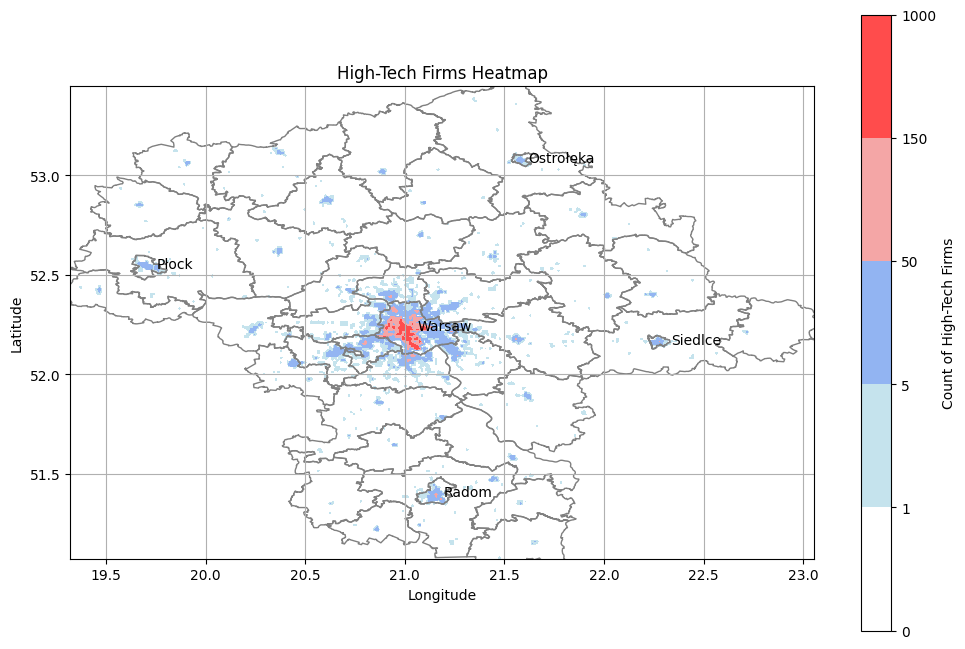

In [19]:
city_lon = [21.017532, 21.14714, 19.70638, 22.29006, 21.5714]
city_lat = [52.237049, 51.40253, 52.54682, 52.16772, 53.0813]
city_names = ['Warsaw', 'Radom', 'Płock', 'Siedlce', 'Ostrołęka']

colors = ['white', 'lightblue', 'cornflowerblue', 'lightcoral', 'red']
bounds = [0, 1, 5, 50, 150, 1000]

cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, len(colors))

ax = powiaty_maz.plot(figsize=(12, 8), color='none', edgecolor='grey')

plt.imshow(heatmap_maz, cmap=cmap, norm=norm, origin='lower', extent=[min_lon_maz, max_lon_maz, min_lat_maz, max_lat_maz], alpha=0.7)

for city, lon, lat in zip(city_names, city_lon, city_lat):
    plt.annotate(city, xy=(lon, lat), xytext=(7, -2), textcoords='offset points', color='black', fontsize=10)

plt.colorbar(label='Count of High-Tech Firms')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('High-Tech Firms Heatmap')

plt.grid(True)
plt.show()


In [20]:
min_lon_waw, max_lon_waw = warsaw['lon'].min(), warsaw['lon'].max()
min_lat_waw, max_lat_waw = warsaw['lat'].min(), warsaw['lat'].max()
grid_size = 0.01182  # Adjust as needed

lons_waw = np.arange(min_lon_waw, max_lon_waw, grid_size)
lats_waw = np.arange(min_lat_waw, max_lat_waw, grid_size)

warsaw_ht['grid_x_waw_ht'] = np.digitize(warsaw_ht['lon'], lons_waw)
warsaw_ht['grid_y_waw_ht'] = np.digitize(warsaw_ht['lat'], lats_waw)

grid_counts_waw = warsaw_ht.groupby(['grid_x_waw_ht', 'grid_y_waw_ht']).size().reset_index(name='firm_count_waw_ht')
warsaw_ht = warsaw_ht.merge(grid_counts_waw, how='left', on=['grid_x_waw_ht', 'grid_y_waw_ht'])

c:\Users\Filip\AppData\Local\Programs\Python\Python312\Lib\site-packages\geopandas\geodataframe.py:1525: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\Filip\AppData\Local\Programs\Python\Python312\Lib\site-packages\geopandas\geodataframe.py:1525: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [21]:
heatmap_waw = np.zeros((len(lats_waw), len(lons_waw)))

for idx, row in grid_counts_waw.iterrows():
    grid_x, grid_y = row['grid_x_waw_ht'] - 1, row['grid_y_waw_ht'] - 1  
    count = row['firm_count_waw_ht']
    heatmap_waw[grid_y, grid_x] = count

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


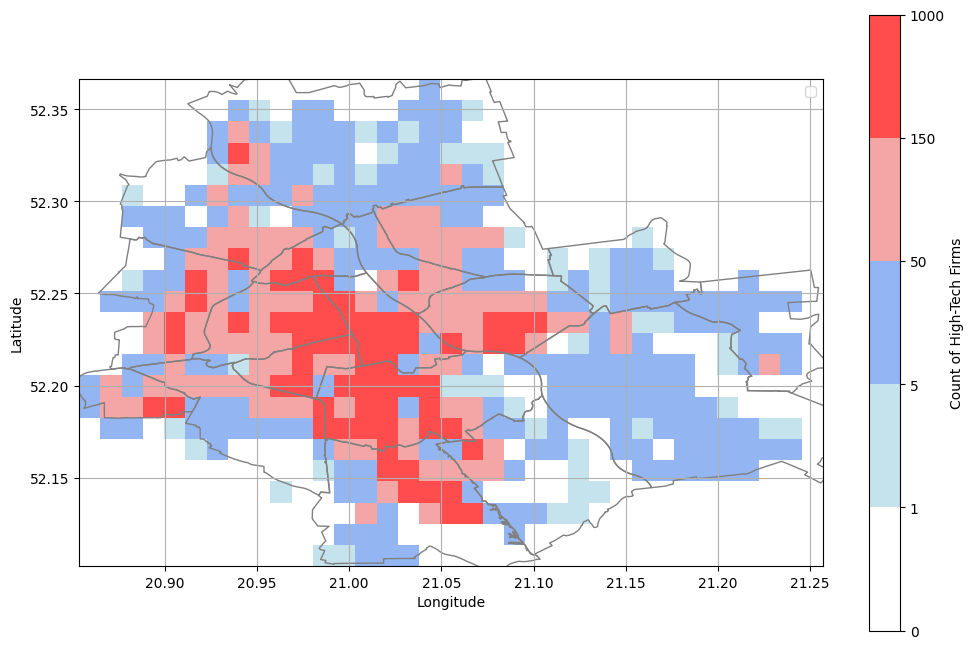

In [22]:
colors = ['white', 'lightblue', 'cornflowerblue', 'lightcoral', 'red']
bounds = [0, 1, 5, 50, 150, 1000]

cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, len(colors))

ax = dzielnice.plot(figsize=(12, 8), color='none', edgecolor='grey')

plt.imshow(heatmap_waw, cmap=cmap, norm=norm, origin='lower', extent=[min_lon_waw, max_lon_waw, min_lat_waw, max_lat_waw], alpha=0.7)

# plt.scatter(warsaw_ht['lon'], warsaw_ht['lat'], color='black', marker='o', s = 0.01)
plt.colorbar(label='Count of High-Tech Firms')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.legend()
plt.grid(True)
plt.show()

c:\Users\Filip\AppData\Local\Programs\Python\Python312\Lib\site-packages\geopandas\geodataframe.py:1525: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\Filip\AppData\Local\Programs\Python\Python312\Lib\site-packages\geopandas\geodataframe.py:1525: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no

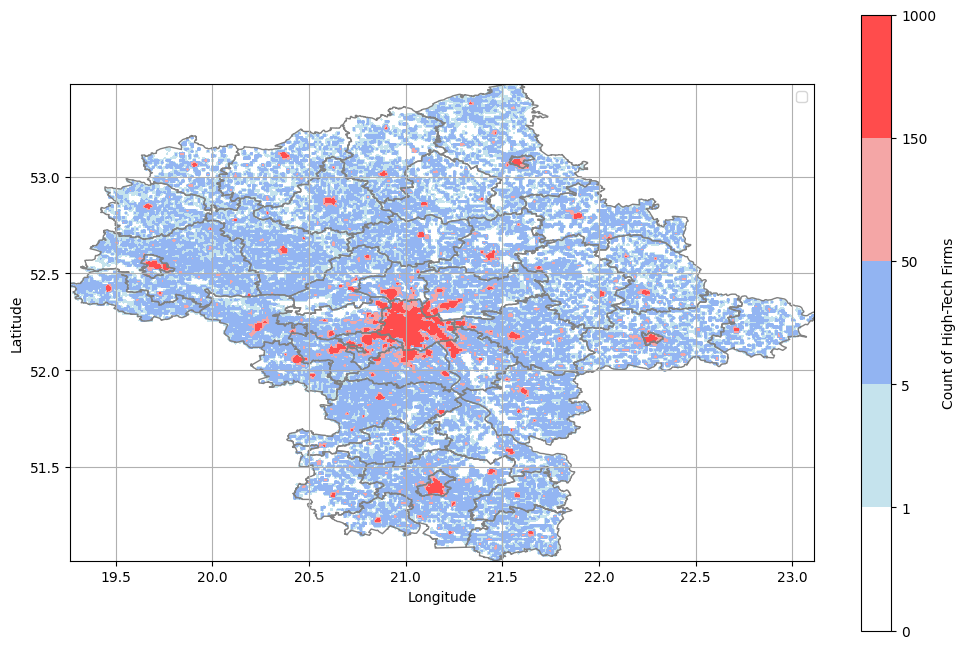

In [51]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy import stats

gdf_non_ht = gdf[gdf['if_hightech'] == 0]

min_lon, max_lon = gdf['lon'].min(), gdf['lon'].max()
min_lat, max_lat = gdf['lat'].min(), gdf['lat'].max()
grid_size = 0.01182 

lons = np.arange(min_lon, max_lon, grid_size)
lats = np.arange(min_lat, max_lat, grid_size)

gdf_non_ht['grid_x'] = np.digitize(gdf_non_ht['lon'], lons)
gdf_non_ht['grid_y'] = np.digitize(gdf_non_ht['lat'], lats)

grid_counts_non_ht = gdf_non_ht.groupby(['grid_x', 'grid_y']).size().reset_index(name='firm_count')

heatmap_non_ht= np.zeros((len(lats), len(lons)))

for idx, row in grid_counts_non_ht.iterrows():
    grid_x, grid_y = row['grid_x'] - 1, row['grid_y'] - 1  
    count = row['firm_count']
    heatmap_non_ht[grid_y, grid_x] = count

colors = ['white', 'lightblue', 'cornflowerblue', 'lightcoral', 'red']
bounds = [0, 1, 5, 50, 150, 1000]

cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, len(colors))

ax = powiaty_maz.plot(figsize=(12, 8), color='none', edgecolor='grey')

plt.imshow(heatmap_non_ht, cmap=cmap, norm=norm, origin='lower', extent=[min_lon, max_lon, min_lat, max_lat], alpha=0.7)

# plt.scatter(warsaw_ht['lon'], warsaw_ht['lat'], color='black', marker='o', s = 0.01)
plt.colorbar(label='Count of High-Tech Firms')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.legend()
plt.grid(True)
plt.show()


C:\Users\Filip\AppData\Local\Temp\ipykernel_30680\2948191952.py:4: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w_queen = lps.weights.Queen.from_dataframe(gdf_ht)
c:\Users\Filip\AppData\Local\Programs\Python\Python312\Lib\site-packages\esda\getisord.py:615: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  warnings.warn(


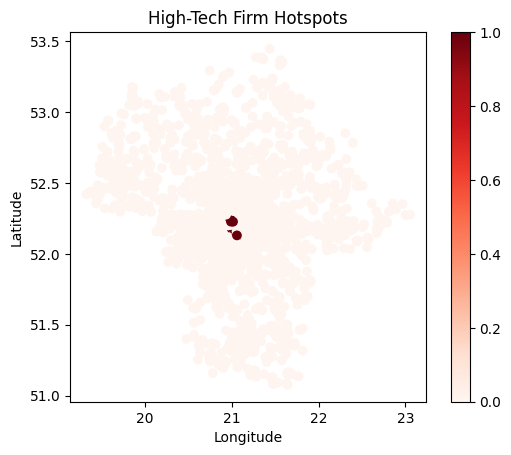

In [69]:
import libpysal as lps
from esda.getisord import G_Local

w_queen = lps.weights.Queen.from_dataframe(gdf_ht)

gi_star = G_Local(gdf_ht['firm_count_maz_ht'], w_queen, transform='r', star=True)

z_scores = gi_star.z_sim
p_values = gi_star.p_sim

significance_threshold = 0.1

hotspot_mask = (z_scores > 0) & (p_values < significance_threshold)

gdf_ht['high_tech_hotspot'] = hotspot_mask.astype(int)


gdf_ht.plot(column='high_tech_hotspot', cmap='Reds', legend=True)
plt.title('High-Tech Firm Hotspots')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


In [53]:

from esda.moran import Moran

w_queen = lps.weights.Queen.from_dataframe(gdf_ht)

moran_i = Moran(gdf_ht['firm_count_maz_ht'], w_queen)

# Print Moran's I statistic and p-value
print("Moran's I:", moran_i.I)
print("P-value:", moran_i.p_sim)


C:\Users\Filip\AppData\Local\Temp\ipykernel_30680\2939187480.py:3: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w_queen = lps.weights.Queen.from_dataframe(gdf_ht)


Moran's I: 0.9737500144334061
P-value: 0.001


In [56]:
from esda import G_Local

# Assuming you have already created a spatial weights matrix (w_distance) and have a variable of interest (e.g., 'firm_count_maz_ht')

# Create a G_Local instance
g_local = G_Local(gdf_ht['firm_count_maz_ht'], w_queen,transform='B')

# Get the Gi* statistics and p-values
g_star = g_local.Gs
p_values = g_local.p_sim

# Print Gi* statistics and p-values
print("Getis-Ord Gi* statistics:", g_star)
print("P-values:", p_values)


Getis-Ord Gi* statistics: [6.33794166e-04 3.52017597e-05 6.27259874e-05 ... 2.17733818e-04
 7.44598294e-05 7.28664261e-05]
P-values: [0.167 0.001 0.051 ... 0.393 0.003 0.009]


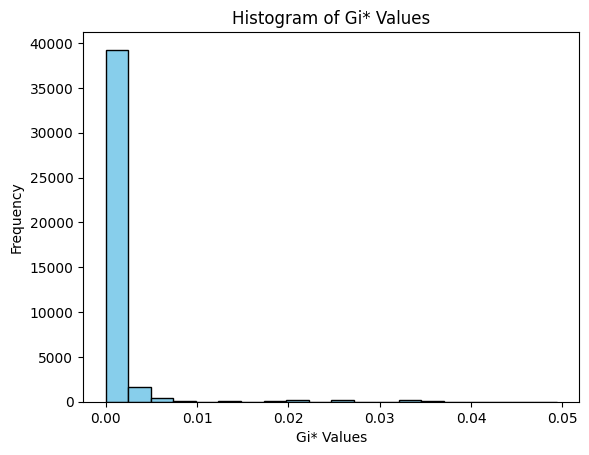

In [62]:
import matplotlib.pyplot as plt

# Assuming you have a list or array of g_star values named g_star_values
# Replace g_star_values with your actual data
g_star_values = g_star

# Plot the histogram
plt.hist(g_star_values, bins=20, color='skyblue', edgecolor='black')

# Add labels and title
plt.xlabel('Gi* Values')
plt.ylabel('Frequency')
plt.title('Histogram of Gi* Values')

# Show the plot
plt.show()
